In [1]:
import os
import glob
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
source_path = '/Users/harryclark/Downloads/COHORT12/'
locations = pd.read_csv('/Users/harryclark/Downloads/all_cluster_brain_locations_chris.csv')
locations['coord_SCs_x'] = locations['coord_SCs_x'] * -1

In [2]:
import math
import numpy as np
import pandas as pd
import pynapple as nap
import matplotlib.pyplot as plt

MEDLAT_THRESHOLD_UM = 3400
TARGET_GC_IDS = [91, 235]

mouse = 25
day   = 25

# ── Cell classification ────────────────────────────────────────────────────────
gcs, ngs, all_cells = classify_cells_both_sessions(mouse, day)
ngs_ids = ngs['cluster_id'].astype(int).tolist()

# ── Assign medlat to each NGS cell via locations CSV ─────────────────────────
loc_sess = locations[
    (locations['mouse'].astype(int) == int(mouse)) &
    (locations['day'].astype(int)   == int(day))
].copy()
loc_sess['cluster_id'] = loc_sess['cluster_id'].astype(int)
loc_sess['medlat'] = np.where(
    loc_sess['coord_SCs_x'].abs() < MEDLAT_THRESHOLD_UM, 'medial', 'lateral'
)
ngs_loc = loc_sess[loc_sess['cluster_id'].isin(ngs_ids)][
    ['cluster_id', 'medlat']
].drop_duplicates(subset=['cluster_id'])
medlat_lookup = dict(zip(ngs_loc['cluster_id'], ngs_loc['medlat']))
print(f"NGS medial: {sum(v=='medial' for v in medlat_lookup.values())}  "
      f"lateral: {sum(v=='lateral' for v in medlat_lookup.values())}")

# ── Load session ───────────────────────────────────────────────────────────────
tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
    mouse, day, apply_zscore=False, apply_guassian_filter=False,
    source_path=source_path,
)
last_ephys_time_bin = clusters[clusters.index[0]].count(
    bin_size=time_bs, time_units='ms'
).index[-1]
ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units='s')

dt_in_time = np.array(
    beh['travel'].bin_average(bin_size=time_bs, time_units='ms', ep=ep)
    - ((beh['trial_number'][0] - 1) * tl)
)
pos_in_time = dt_in_time % tl
if np.any(np.isnan(pos_in_time)):
    pos_in_time = pd.Series(dt_in_time).ffill().bfill().values % tl
trial_number_in_time = (dt_in_time // tl) + beh['trial_number'][0]

# ── XGBoost model ─────────────────────────────────────────────────────────────
xgb_history = MLencoding(
    tunemodel='xgboost', cov_history=True, spike_history=False,
    window=time_bs, n_filters=5, max_time=1000,
)

# ── Build trial-by-position maps for all NGS cells (done once) ────────────────
n_pos_bins = int(np.ceil(tl / bs))

def build_trial_position_map(spikes_t, pos_t, trial_t, n_bins):
    trial_ids = np.unique(trial_t.astype(int))
    mat = np.full((len(trial_ids), n_bins), np.nan)
    pbin = np.clip(
        np.floor(np.clip(pos_t, 0, tl - 1e-9) / bs).astype(int),
        0, n_bins - 1
    )
    for i, tr in enumerate(trial_ids):
        m = trial_t.astype(int) == tr
        if not np.any(m):
            continue
        sums   = np.bincount(pbin[m], weights=spikes_t[m], minlength=n_bins)
        counts = np.bincount(pbin[m], minlength=n_bins)
        with np.errstate(divide='ignore', invalid='ignore'):
            mat[i] = sums / counts
        mat[i, counts == 0] = np.nan
    return mat

cell_maps = {}
for cid in ngs_ids:
    if cid not in tcs_time:
        continue
    y  = np.asarray(tcs_time[cid])
    T  = len(y)
    cell_maps[cid] = build_trial_position_map(y, pos_in_time[:T], trial_number_in_time[:T], n_pos_bins)
print(f"Built trial-position maps for {len(cell_maps)} NGS cells")

# ── Compute pR² per target GC × individual NGS cell ───────────────────────────
# Models: (1) P only, (2) NGS only, (3) NGS + P
all_rows = []

for target_id in TARGET_GC_IDS:
    if target_id not in tcs_time:
        print(f"Target GC {target_id} not in tcs_time — skipping")
        continue

    y = np.asarray(tcs_time[target_id])
    T = len(y)
    pos = pos_in_time[:T]
    if len(pos) < T:
        pos = np.pad(pos, (0, T - len(pos)), mode='edge')

    # Model 1: position only (one per target, shared across all NGS comparisons)
    _, pR2_pos_cv = xgb_history.fit_cv(pos[:, None], y, verbose=0, continuous_folds=True)
    pR2_pos_val = float(np.nanmean(pR2_pos_cv))
    print(f"\n{'='*60}")
    print(f"Target GC {target_id}  |  pR²(P) = {pR2_pos_val:.4f}")
    print(f"{'='*60}")

    for ngs_id in ngs_ids:
        if ngs_id not in tcs_time:
            continue

        ngs_y   = np.asarray(tcs_time[ngs_id])
        ngs_vec = np.pad(ngs_y[:T], (0, max(0, T - len(ngs_y[:T]))), mode='constant')
        medlat  = medlat_lookup.get(ngs_id, 'unknown')

        # Model 2: NGS cell only
        _, pR2_ngs_cv = xgb_history.fit_cv(ngs_vec[:, None], y, verbose=0, continuous_folds=True)
        pR2_ngs_val = float(np.nanmean(pR2_ngs_cv))

        # Model 3: position + NGS cell
        X_pn = np.column_stack([pos, ngs_vec])
        _, pR2_pn_cv = xgb_history.fit_cv(X_pn, y, verbose=0, continuous_folds=True)
        pR2_pn_val = float(np.nanmean(pR2_pn_cv))

        delta = pR2_pn_val - pR2_pos_val

        print(f"  NGS {ngs_id:4d} ({medlat:7s})  "
              f"pR²(NGS)={pR2_ngs_val:.4f}  "
              f"pR²(P+NGS)={pR2_pn_val:.4f}  "
              f"Δ={delta:+.4f}")

        all_rows.append(dict(
            target_cluster_id = target_id,
            ngs_cluster_id    = ngs_id,
            medlat            = medlat,
            pR2_pos           = pR2_pos_val,
            pR2_ngs           = pR2_ngs_val,
            pR2_pos_ngs       = pR2_pn_val,
            delta_pr2         = delta,
        ))

results_df = pd.DataFrame(all_rows)
results_df = results_df.sort_values(
    ['target_cluster_id', 'delta_pr2'], ascending=[True, False]
).reset_index(drop=True)

print("\n\nFull results dataframe (sorted by target then ΔpR²):")
print(results_df.to_string())
    

NGS medial: 11  lateral: 38
Built trial-position maps for 49 NGS cells

Target GC 91  |  pR²(P) = 0.0312
  NGS    1 (medial )  pR²(NGS)=0.0088  pR²(P+NGS)=0.0405  Δ=+0.0094
  NGS   13 (medial )  pR²(NGS)=0.0085  pR²(P+NGS)=0.0405  Δ=+0.0094
  NGS   16 (medial )  pR²(NGS)=-0.0023  pR²(P+NGS)=0.0301  Δ=-0.0011
  NGS   17 (medial )  pR²(NGS)=0.0019  pR²(P+NGS)=0.0372  Δ=+0.0061
  NGS   72 (medial )  pR²(NGS)=0.0682  pR²(P+NGS)=0.0948  Δ=+0.0636
  NGS   73 (medial )  pR²(NGS)=0.0065  pR²(P+NGS)=0.0393  Δ=+0.0081
  NGS   80 (medial )  pR²(NGS)=0.0105  pR²(P+NGS)=0.0438  Δ=+0.0127
  NGS  102 (medial )  pR²(NGS)=0.0364  pR²(P+NGS)=0.0662  Δ=+0.0350
  NGS  112 (medial )  pR²(NGS)=0.0098  pR²(P+NGS)=0.0410  Δ=+0.0098
  NGS  123 (medial )  pR²(NGS)=0.0101  pR²(P+NGS)=0.0409  Δ=+0.0097
  NGS  127 (medial )  pR²(NGS)=0.0014  pR²(P+NGS)=0.0343  Δ=+0.0031
  NGS  169 (lateral)  pR²(NGS)=-0.0004  pR²(P+NGS)=0.0328  Δ=+0.0017
  NGS  172 (lateral)  pR²(NGS)=0.0035  pR²(P+NGS)=0.0318  Δ=+0.0007
  NGS  17

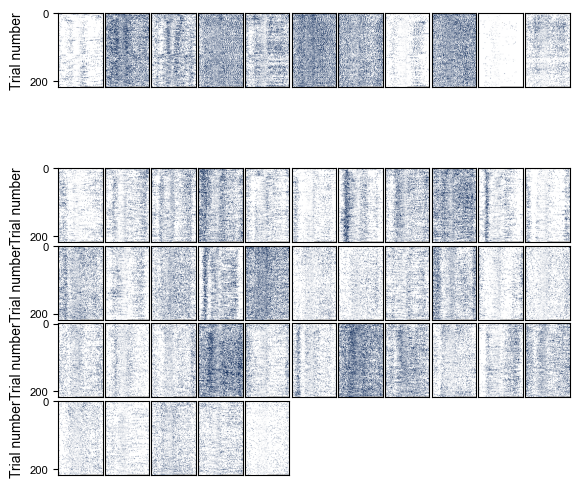

Saved → /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/ngs_trial_position_grid_M25_D25_GC91_medial_lateral.pdf


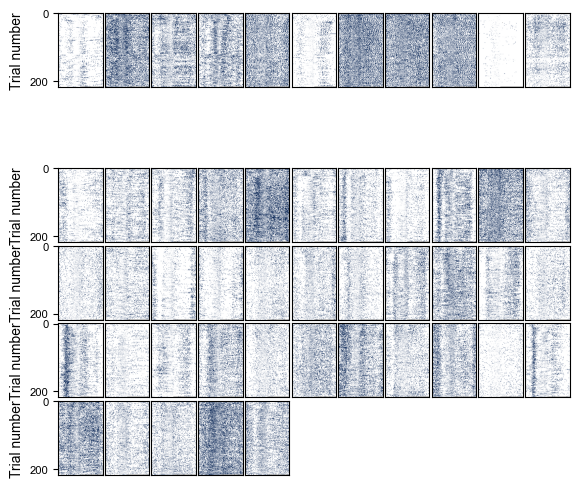

Saved → /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/ngs_trial_position_grid_M25_D25_GC235_medial_lateral.pdf


In [ ]:
        
# ── Plot: one figure per target GC ────────────────────────────────────────────
content_rows = 5
gap_rows     = 1

for target_id in TARGET_GC_IDS:
    df_t = results_df[results_df['target_cluster_id'] == target_id].copy()
    if df_t.empty:
        continue

    medial_cells  = (df_t[df_t['medlat'] == 'medial']
                     .sort_values('delta_pr2', ascending=False))
    lateral_cells = (df_t[df_t['medlat'] == 'lateral']
                     .sort_values('delta_pr2', ascending=False))

    medial_ids  = [c for c in medial_cells['ngs_cluster_id'].astype(int).tolist()
                   if c in cell_maps]
    lateral_ids = [c for c in lateral_cells['ngs_cluster_id'].astype(int).tolist()
                   if c in cell_maps]
    total_cells = len(medial_ids) + len(lateral_ids)

    if total_cells == 0:
        print(f"No plottable NGS cells for target GC {target_id}")
        continue

    # Row allocation
    if medial_ids and lateral_ids:
        medial_row_count = int(np.clip(
            np.round(content_rows * len(medial_ids) / total_cells), 1, content_rows - 1
        ))
    elif medial_ids:
        medial_row_count = content_rows
    else:
        medial_row_count = 0
    lateral_row_count = content_rows - medial_row_count

    n_cols = max(
        1,
        math.ceil(len(medial_ids)  / medial_row_count)  if medial_row_count  > 0 else 1,
        math.ceil(len(lateral_ids) / lateral_row_count) if lateral_row_count > 0 else 1,
    )
    n_rows_total = medial_row_count + gap_rows + lateral_row_count

    fig, axes = plt.subplots(
        nrows=n_rows_total, ncols=n_cols,
        figsize=(n_cols * 0.6, n_rows_total * 1),
        sharex=False, sharey=False,
    )
    if n_rows_total == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows_total == 1:
        axes = np.array([axes])
    elif n_cols == 1:
        axes = np.array([[ax] for ax in axes])

    # Consistent color scale across all NGS maps for this target
    plot_ids = medial_ids + lateral_ids
    all_vals = np.concatenate([
        np.ravel(cell_maps[c][np.isfinite(cell_maps[c])])
        for c in plot_ids if np.any(np.isfinite(cell_maps[c]))
    ])
    vmin = np.nanpercentile(all_vals, 5)  if len(all_vals) else 0
    vmax = np.nanpercentile(all_vals, 95) if len(all_vals) else 1

    for r in range(n_rows_total):
        for c in range(n_cols):
            axes[r, c].axis('off')

    def _plot_group(ids, start_row, n_rows_group):
        for k, cid in enumerate(ids):
            rr = k // n_cols
            cc = k % n_cols
            if rr >= n_rows_group:
                break
            ax  = axes[start_row + rr, cc]
            m   = cell_maps[cid]
            #vmin = np.nanpercentile(m, 5)  if np.any(np.isfinite(m)) else 0
            #vmax = np.nanpercentile(m, 95) if np.any(np.isfinite(m)) else 1
            ax.imshow(m, aspect='auto', origin='lower', cmap=white_to_hex_cmap('#0d2958'), vmin=vmin, vmax=vmax)
            row = df_t[df_t['ngs_cluster_id'] == cid]
            d   = float(row['delta_pr2'].iloc[0]) if len(row) else np.nan
            p   = float(row['pR2_pos'].iloc[0])   if len(row) else np.nan
            n_  = float(row['pR2_ngs'].iloc[0])   if len(row) else np.nan
            #ax.set_title(f'C{cid}\nΔ={d:+.3f}  N={n_:.3f}', fontsize=5)
            ax.set_xticks([]); ax.set_yticks([])
            ax.axis('on')
            ax.invert_yaxis()  
            #for spine in ax.spines.values():
            #    spine.set_visible(False)
            if cc == 0:
                yticks = [0, (m.shape[0]-1)-((m.shape[0] - 1)%100)]
                y_tick_labels = [str(int(tick)) for tick in yticks]
                ax.set_yticks(yticks)
                ax.set_yticklabels(y_tick_labels, rotation=0, fontsize=8)

                ax.set_ylabel('Trial number')
    _plot_group(medial_ids,  0,                            medial_row_count)
    for c in range(n_cols):
        axes[medial_row_count, c].axis('off')
    _plot_group(lateral_ids, medial_row_count + gap_rows,  lateral_row_count)

    pR2_pos_val = float(df_t['pR2_pos'].iloc[0])
    #fig.text(0.01, 0.995, f'Medial NGS  (n={len(medial_ids)})',
    #         ha='left', va='top', fontsize=9, fontweight='bold', color='#0d2958')
    #fig.text(0.01, (lateral_row_count + gap_rows) / n_rows_total + 0.005,
    #         f'Lateral NGS  (n={len(lateral_ids)})',
    #         ha='left', va='top', fontsize=9, fontweight='bold', color='#29d8de')
    #fig.suptitle(
    #    f'Target GC {target_id} — M{mouse} D{day}   pR²(P)={pR2_pos_val:.3f}\n'
    #    f'NGS sorted by Δ = pR²(P+NGS) − pR²(P)   N = pR²(NGS only)',
    #    y=1.01, fontsize=9,
    #)

    #mappable = plt.cm.ScalarMappable(cmap=white_to_hex_cmap('#0d2958'))
    #mappable.set_clim(vmin, vmax)
    #cbar = fig.colorbar(mappable, ax=axes.ravel().tolist(), fraction=0.015, pad=0.01)
    #cbar.set_label('Firing rate (spk/bin)', fontsize=8)

    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    save_path = (
        f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/'
        f'ngs_trial_position_grid_M{mouse}_D{day}_GC{target_id}_medial_lateral.pdf'
    )
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved → {save_path}")

In [57]:
# For each good example cell, reconstruct firing rate profiles using xgboost predictions
# You will need to fill in the details for loading tcs_time, pos_in_time, and MLencoding setup

# set up xgboost history model
xgb_history = MLencoding(tunemodel='xgboost', cov_history=True, spike_history=False,
                            window=time_bs, n_filters=5, max_time=1000)

filtered_good_examples = [(25,25,91), (25,25,235)]
for mouse, day, cluster_id in filtered_good_examples:
    print(f"\nMouse: {mouse}, Day: {day}, Cluster: {cluster_id}")
    gcs, ngs, all = classify_cells_both_sessions(mouse, day) # subset
    _gcs_ids = set(gcs['cluster_id']) if len(gcs) > 0 else set()
    _ngs_ids = set(ngs['cluster_id']) if len(ngs) > 0 else set()
    gc_ngs_ids = _gcs_ids.union(_ngs_ids)
    ns = all[~all['cluster_id'].isin(gc_ngs_ids)].copy().reset_index(drop=True)

    tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse,day, apply_zscore=False, apply_guassian_filter=False)
    last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units = 'ms').index[-1]

    # time binned variables for later
    ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units = 's')
    speed_in_time = np.array(beh['S'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep))
    dt_in_time = np.array(beh['travel'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)-((beh['trial_number'][0]-1)*tl))
    pos_in_time = dt_in_time%tl
    trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

    if np.any(np.isnan(pos_in_time)):
        series = pd.Series(dt_in_time)
        filled_series = series.ffill().bfill()
        dt_in_time = np.array(filled_series)
        pos_in_time = dt_in_time%tl
        trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

    if np.any(np.isnan(speed_in_time)):
        series = pd.Series(speed_in_time)
        filled_series = series.ffill().bfill()
        speed_in_time = np.array(filled_series)

    # Get the target cell's firing rate
    target_fr = tcs_time[cluster_id]

    locations = pd.read_csv(f'{source_path}/all_cluster_brain_locations_chris.csv')
    locations = locations[(locations['mouse'] == mouse) & (locations['day'] == day)]
    locations['coord_SCs_x'] = locations['coord_SCs_x'] * -1  # correct for the flipped SCs x coordinates

    # Set up 4-column plot: True, Pos-only, Medial, Lateral
    fig, ax = plt.subplots(ncols=4, nrows=3, figsize=(rm_figsize[0]*3.2, rm_figsize[1]*1.7), 
                           sharex=False, sharey='row', height_ratios=[0.6, 0.25, 1], width_ratios=[1,1,1,1])
    plt.subplots_adjust(wspace=0.38, hspace=0.35)

    # --- Annotation plot above Pos-only column (no cells highlighted) ---
    annotations, annotation_colors, xs, ys = make_annotations(mouse, path='/Users/harryclark/Documents/spatial-manifolds/data')
    unique_colors = np.unique(annotation_colors)
    for color_ in unique_colors:
        border_points = extract_border(annotation_colors, color_, only_border=False)
        x_points = xs[border_points[:, 1]]
        y_points = ys[border_points[:, 0]]
        ax[0,1].scatter(x_points, y_points, color=color_, s=1, label=color_, rasterized=True)
    plot_NP2_probe(ax[0,1], sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa', 
                probe_alpha=0.5, contacts_alpha=0.0, probe_color='grey', probe_edgecolor='black')
    min_y = 2000
    max_y = 1000
    ax[0,1].set_ylim([min_y, max_y])
    ax[0,1].set_xlim([-100, 900])
    ax[0,1].spines['top'].set_visible(True)
    ax[0,1].spines['right'].set_visible(True)
    ax[0,1].spines['bottom'].set_visible(True)
    ax[0,1].spines['left'].set_visible(True)

    # --- True rate map ---
    tc = tcs[cluster_id]
    tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
    tc = tc[:last_ephys_bin] # only want bins with ephys data in it
    tcz = zscore(tc)
    print(f'plotting true rate map')
    plot_firing_rate_map(ax[2,0], tc, bs=bs, tl=tl, p=95, sort_indices=None, cmap=white_to_hex_cmap('#90312a'))
    ax[1,0].set_title('True', fontsize=5)

    # --- Position-only (n=0) reconstruction ---
    X_posonly = pos_in_time.reshape(-1, 1)
    Y_hat_pos, pR2_cv_pos = xgb_history.fit_cv(X_posonly, target_fr, verbose=0, continuous_folds=True)
    print(f'for cell {cluster_id}, avg pR2 (pos only) is {np.nanmean(pR2_cv_pos)}, using 0 covariate cells')
    expected_spikes_pos = {ns.cluster_id.values[0]: Y_hat_pos}
    tcs_expected_spikes_pos, _, _ , last_ephys_bin, beh, _ = compute_vr_tcs_using_expected_spikes(
        mouse, day, apply_zscore=False, apply_guassian_filter=False, vr_type='VR', source_path=source_path, expected_spikes=expected_spikes_pos)
    tc_es_pos = tcs_expected_spikes_pos[ns.cluster_id.values[0]]
    tc_es_pos = gaussian_filter(np.nan_to_num(tc_es_pos).astype(np.float64), sigma=2.5)
    tc_es_pos = tc_es_pos[:last_ephys_bin]
    plot_firing_rate_map(ax[2,1], tc_es_pos, bs=bs, tl=tl, p=95, sort_indices=None, cmap=white_to_hex_cmap('#90312a'))
    ax[1,1].set_title(f'Pos only (n=0)\npr²: {np.nanmean(pR2_cv_pos):.2f}', fontsize=5)

    # Plot average firing rate profile for Pos only
    trial_groups, trial_colors = get_trial_groups_and_colors(beh, last_ephys_bin, tl, bs, ignore_performance=True)
    for group in np.unique(trial_groups):
        if len(trial_groups[trial_groups == group]) > 5:
            x, y = get_avg_profile(tc_es_pos, bs, tl, mask=trial_groups==group)
            ax[1,1].plot(x, y, color=trial_colors[trial_groups==group][0], linewidth=1)
    # Only allow max two y ticks on 2nd row
    for col in range(4):
        ax[1,col].yaxis.set_major_locator(plt.MaxNLocator(nbins=2, integer=True))
    # Remove axis from 1st row, 2nd column only
    ax[0,1].axis('off')

    # --- Medial and Lateral reconstructions ---
    tidy_labels = {'medial_MEC': 'P + mNGS', 'lateral_MEC': 'P + lNGS'}
    for cov_idx, cov_label in enumerate(['medial_MEC', 'lateral_MEC']):
        # Get covariate NGS cluster_ids in the correct ML bin
        cov_bounds = (-np.inf, 3400) if cov_label == 'medial_MEC' else (3400, np.inf)
        covariate_cluster_ids = ngs.cluster_id.values.astype(int)
        covariate_cluster_ids = covariate_cluster_ids[
            np.isin(
                covariate_cluster_ids,
                locations[
                    (locations['coord_SCs_x'] >= cov_bounds[0]) &
                    (locations['coord_SCs_x'] < cov_bounds[1])
                ]['cluster_id'].values.astype(int)
            )
        ]

        # Build covariate matrix X (n_timepoints x n_covariate_cells)
        cov_tcs_time = {cid: tcs_time[cid] for cid in covariate_cluster_ids if cid in tcs_time}
        if len(cov_tcs_time) == 0:
            print(f"No covariate cells found for {cov_label}")
            continue
        X = np.vstack(list(cov_tcs_time.values())).T
        X = np.column_stack((pos_in_time, X))
        n_cov_cells = len(X.T)-1 # subtract 1 for position
        Y_hat, pR2_cv = xgb_history.fit_cv(X, target_fr, verbose=0, continuous_folds=True)
        print(f'for cell {cluster_id}, avg pR2 is {np.nanmean(pR2_cv)}, for {cov_label}, using {n_cov_cells} covariate cells')
        expected_spikes = {ns.cluster_id.values[0]: Y_hat}
        tcs_expected_spikes, _, _ , last_ephys_bin, beh, _ = compute_vr_tcs_using_expected_spikes(
            mouse, day, apply_zscore=False, apply_guassian_filter=False, vr_type='VR', source_path=source_path, expected_spikes=expected_spikes)
        tc_es = tcs_expected_spikes[ns.cluster_id.values[0]]
        tc_es = gaussian_filter(np.nan_to_num(tc_es).astype(np.float64), sigma=2.5)
        tc_es = tc_es[:last_ephys_bin]
        plot_firing_rate_map(ax[2,cov_idx+2], tc_es, bs=bs, tl=tl, p=95, sort_indices=None, cmap=white_to_hex_cmap('#90312a'))
        ax[1,cov_idx+2].set_title(f'{tidy_labels[cov_label]} (n={n_cov_cells})\npr²: {np.nanmean(pR2_cv):.2f}', fontsize=5)

        # Plot trial-averaged profiles for each group
        for group in np.unique(trial_groups):
            if len(trial_groups[trial_groups == group]) > 5:
                x, y = get_avg_profile(tc, bs, tl, mask=trial_groups==group)
                if cov_idx == 0:
                    ax[1,0].plot(x, y, color=trial_colors[trial_groups==group][0], linewidth=1)
                x, y = get_avg_profile(tc_es, bs, tl, mask=trial_groups==group)
                ax[1,cov_idx+2].plot(x, y, color=trial_colors[trial_groups==group][0], linewidth=1)

        # Plot probe locations and cell highlights for each covariate column
        annotations, annotation_colors, xs, ys = make_annotations(mouse, path='/Users/harryclark/Documents/spatial-manifolds/data')
        unique_colors = np.unique(annotation_colors)
        for color_ in unique_colors:
            border_points = extract_border(annotation_colors, color_, only_border=False)
            x_points = xs[border_points[:, 1]]
            y_points = ys[border_points[:, 0]]
            ax[0,cov_idx+2].scatter(x_points, y_points, color=color_, s=1, label=color_, rasterized=True)
        plot_NP2_probe(ax[0,cov_idx+2], sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa', 
                    probe_alpha=0.5, contacts_alpha=0.0, probe_color='grey', probe_edgecolor='black')
        ax[0,cov_idx+2].scatter(ngs.probe_x.values, ngs.probe_y.values, marker='o', color="grey", alpha=0.4, s=7)
        ax[0,cov_idx+2].scatter(gcs.probe_x.values, gcs.probe_y.values, marker='o', color="grey", alpha=0.4, s=7)
        min_y = min(all['probe_y'].values) - 300
        max_y = max(all['probe_y'].values) + 300
        target_id = cluster_id
        target_row = all[all['cluster_id'] == target_id]
        # Move star scatter after all other scatter points for highest zorder
        if not target_row.empty:
            x_t, y_t = target_row['probe_x'].values[0], target_row['probe_y'].values[0]
            ax[0,cov_idx+2].scatter(x_t, y_t, marker='*', s=120, color='white', edgecolor='black', linewidth=0.7, zorder=100)
        cov_row = all[np.isin(all['cluster_id'], covariate_cluster_ids)]
        if not cov_row.empty:
            for _, row in cov_row.iterrows():
                x_c, y_c = row['probe_x'], row['probe_y']
                from matplotlib.patches import Circle
                circ2 = Circle((x_c, y_c), radius=20, edgecolor='#0d2958', facecolor='#0d2958', lw=2, alpha=0.6, zorder=12)
                ax[0,cov_idx+2].add_patch(circ2)
        ax[0,cov_idx+2].set_ylim([min_y, max_y])
        ax[0,cov_idx+2].set_xlim([-100, 900])
        ax[0,cov_idx+2].spines['top'].set_visible(True)
        ax[0,cov_idx+2].spines['right'].set_visible(True)
        ax[0,cov_idx+2].spines['bottom'].set_visible(True)
        ax[0,cov_idx+2].spines['left'].set_visible(True)

    # Set axis labels and hide unused axes
    ax[2,0].set_xlabel('Pos (cm)')
    ax[2,1].set_xlabel('Pos (cm)')
    ax[2,2].set_xlabel('Pos (cm)')
    ax[2,3].set_xlabel('Pos (cm)')
    # Only show y tick labels on the 3rd row, 1st column
    ax[2,1].set_yticklabels([])
    ax[2,2].set_yticklabels([])
    ax[2,3].set_yticklabels([])
    ax[1,2].set_xticks([])
    ax[1,3].set_xticks([])
    ax[1,1].set_xticks([])
    ax[1,0].set_xticks([])
    ax[1,0].set_xlim([0,200])
    ax[1,1].set_xlim([0,200])
    ax[1,2].set_xlim([0,200])
    ax[1,3].set_xlim([0,200])
    ax[0,0].axis('off')
    plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/example_cell_{mouse}_day{day}_cluster{cluster_id}.pdf', dpi=300, bbox_inches='tight')
    plt.show()


    


Mouse: 25, Day: 25, Cluster: 91


KeyboardInterrupt: 

In [72]:
from matplotlib.patches import Circle
import matplotlib.gridspec as gridspec

TARGET_GC_IDS = [91]


TOP_N    = 5
N_GCOLS  = 20        # LCM(4, 5): rows 0-1 use 4-wide slots (5/row), rows 2-3 use 5-wide slots (4/row)
COV_SLOT = N_GCOLS // TOP_N   # = 4 cols per covariate subplot
RM_SLOT  = N_GCOLS // 4       # = 5 cols per rate-map / probe subplot

# ── Neutral cell for expected-spikes reconstruction ────────────────────────────
_gc_id_set  = set(gcs['cluster_id'].astype(int))
_ngs_id_set = set(ngs['cluster_id'].astype(int))
ns    = all_cells[~all_cells['cluster_id'].isin(_gc_id_set | _ngs_id_set)].copy().reset_index(drop=True)
ns_id = int(ns['cluster_id'].values[0])

# Session locations (sign already corrected in cell 1)
loc_sess = locations[
    (locations['mouse'].astype(int) == int(mouse)) &
    (locations['day'].astype(int)   == int(day))
].copy()
loc_sess['cluster_id'] = loc_sess['cluster_id'].astype(int)

for target_id in TARGET_GC_IDS:
    df_t = results_df[results_df['target_cluster_id'] == target_id].copy()
    if df_t.empty:
        continue

    # ── Top-N NGS cells per region sorted by ΔpR² ────────────────────────────
    medial_plot_ids  = [c for c in df_t[df_t['medlat'] == 'medial']
                        .sort_values('delta_pr2', ascending=False)
                        ['ngs_cluster_id'].astype(int).tolist()
                        if c in cell_maps][:TOP_N]
    lateral_plot_ids = [c for c in df_t[df_t['medlat'] == 'lateral']
                        .sort_values('delta_pr2', ascending=False)
                        ['ngs_cluster_id'].astype(int).tolist()
                        if c in cell_maps][:TOP_N]

    target_fr = np.asarray(tcs_time[target_id])
    T   = len(target_fr)
    pos = pos_in_time[:T]
    if len(pos) < T:
        pos = np.pad(pos, (0, T - len(pos)), mode='edge')

    # ── P-only model ───────────────────────────────────────────────────────────
    Y_hat_pos, pR2_cv_pos = xgb_history.fit_cv(
        pos.reshape(-1, 1), target_fr, verbose=0, continuous_folds=True
    )
    pR2_pos_val = float(np.nanmean(pR2_cv_pos))
    print(f"\n{'='*60}\nGC {target_id}  pR²(P) = {pR2_pos_val:.4f}")

    tcs_es_pos, _, _, last_eb, _, _ = compute_vr_tcs_using_expected_spikes(
        mouse, day, apply_zscore=False, apply_guassian_filter=False,
        vr_type='VR', source_path=source_path, expected_spikes={ns_id: Y_hat_pos}
    )
    tc_es_pos = gaussian_filter(
        np.nan_to_num(tcs_es_pos[ns_id]).astype(np.float64), sigma=2.5
    )[:last_eb]

    # ── P+NGS models per region ────────────────────────────────────────────────
    recon = {}
    for region, cov_bounds in [('medial', (-np.inf, 3400)), ('lateral', (3400, np.inf))]:
        region_ids = set(
            loc_sess[
                (loc_sess['coord_SCs_x'] >= cov_bounds[0]) &
                (loc_sess['coord_SCs_x'] <  cov_bounds[1])
            ]['cluster_id'].values.astype(int)
        )
        cov_ids = np.array([c for c in ngs['cluster_id'].astype(int)
                            if c in region_ids and c in tcs_time])
        if len(cov_ids) == 0:
            print(f"  {region}: no covariate cells in tcs_time")
            recon[region] = None
            continue

        ngs_mat = np.vstack([
            np.pad(np.asarray(tcs_time[c])[:T],
                   (0, max(0, T - len(np.asarray(tcs_time[c])[:T]))),
                   mode='constant')
            for c in cov_ids
        ]).T
        X_cov = np.column_stack([pos, ngs_mat])

        Y_hat_cov, pR2_cv_cov = xgb_history.fit_cv(
            X_cov, target_fr, verbose=0, continuous_folds=True
        )
        pR2_cov_val = float(np.nanmean(pR2_cv_cov))
        print(f"  {region}  pR²(P+NGS, n={len(cov_ids)}) = {pR2_cov_val:.4f}")

        tcs_es_cov, _, _, _, _, _ = compute_vr_tcs_using_expected_spikes(
            mouse, day, apply_zscore=False, apply_guassian_filter=False,
            vr_type='VR', source_path=source_path, expected_spikes={ns_id: Y_hat_cov}
        )
        tc_es_cov = gaussian_filter(
            np.nan_to_num(tcs_es_cov[ns_id]).astype(np.float64), sigma=2.5
        )[:last_eb]

        recon[region] = dict(tc_es=tc_es_cov, pR2=pR2_cov_val, cov_ids=cov_ids)

    # True spatial rate map
    tc_true = gaussian_filter(
        np.nan_to_num(tcs[target_id]).astype(np.float64), sigma=2.5
    )[:last_eb]


GC 91  pR²(P) = 0.0312
using expected spikes for cell 8
  medial  pR²(P+NGS, n=11) = 0.1247
using expected spikes for cell 8
  lateral  pR²(P+NGS, n=38) = 0.0599
using expected spikes for cell 8


hi
hi


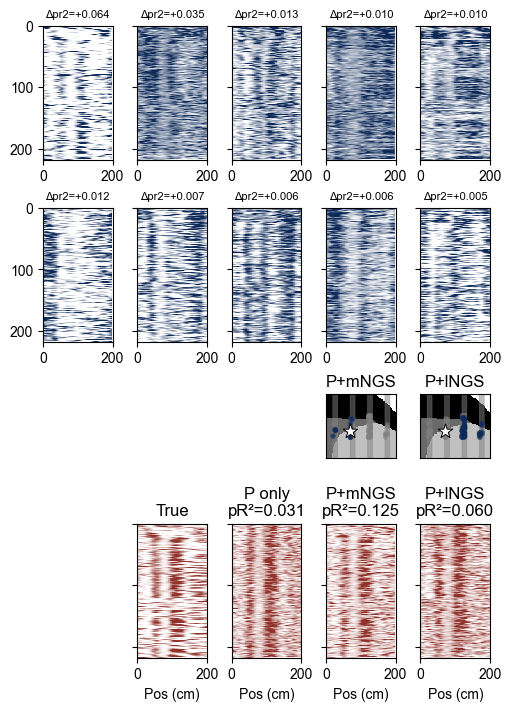

Saved → /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/combined_GC91_M25_D25.pdf


In [71]:
# ── Figure: 4 rows × 5 cols ────────────────────────────────────────────────
fig, axs = plt.subplots(
    4, 5,
    figsize=(5, 7),
    constrained_layout=True,
    width_ratios=[1,1,1,1,1],
    height_ratios=[1.3,1.3,1,1.3],
    sharey='row'
)

# ── Rows 0-1: covariate trial-position maps ────────────────────────────────
cov_all = np.concatenate([
    np.ravel(cell_maps[c][np.isfinite(cell_maps[c])])
    for c in medial_plot_ids + lateral_plot_ids
    if c in cell_maps and np.any(np.isfinite(cell_maps[c]))
]) if (len(medial_plot_ids) or len(lateral_plot_ids)) else np.array([0.0, 1.0])

cov_vmin, cov_vmax = np.nanpercentile(cov_all, 5), np.nanpercentile(cov_all, 95)


def _draw_cov_row(ids, row):
    for col in range(5):

        ax_ = axs[row, col]

        if col >= len(ids):
            ax_.axis('off')
            continue

        cid = ids[col]

        tc = gaussian_filter(
            np.nan_to_num(tcs[cid]).astype(np.float64),
            sigma=2.5
        )
        tc = tc[:last_ephys_bin]

        plot_firing_rate_map(
            ax_,
            tc,
            bs=bs,
            tl=tl,
            p=95,
            sort_indices=None,
            cmap=white_to_hex_cmap('#0d2958')
        )

        row_d = df_t[df_t['ngs_cluster_id'] == cid]
        d = float(row_d['delta_pr2'].iloc[0]) if len(row_d) else np.nan

        ax_.set_title(
            f'Δpr2={d:+.3f}', fontsize=8
        )


_draw_cov_row(medial_plot_ids[:5], row=0)
_draw_cov_row(lateral_plot_ids[:5], row=1)

# ── Row 2: annotated probe maps ────────────────────────────────────────────
annotations_a, ann_colors_a, xs_a, ys_a = make_annotations(
    mouse,
    path='/Users/harryclark/Documents/spatial-manifolds/data'
)


def _draw_anatomy(ax_):

    for col_ in np.unique(ann_colors_a):
        bp = extract_border(
            ann_colors_a,
            col_,
            only_border=False
        )

        ax_.scatter(
            xs_a[bp[:, 1]],
            ys_a[bp[:, 0]],
            color=col_,
            s=1,
            rasterized=True
        )

    plot_NP2_probe(
        ax_,
        sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa',
        probe_alpha=0.5,
        contacts_alpha=0.0,
        probe_color='grey',
        probe_edgecolor='black'
    )

    for sp in ax_.spines.values():
        sp.set_visible(True)


# Col 0: blank (True map has no probe)
axs[2, 0].axis('off')

# Cols 2-3: medial / lateral
for col, region in zip([3, 4], ['medial', 'lateral']):

    ax_p = axs[2, col]

    _draw_anatomy(ax_p)

    ax_p.scatter(
        ngs['probe_x'].values,
        ngs['probe_y'].values,
        marker='o',
        color='grey',
        alpha=0.4,
        s=7
    )

    ax_p.scatter(
        gcs['probe_x'].values,
        gcs['probe_y'].values,
        marker='o',
        color='grey',
        alpha=0.4,
        s=7
    )

    tgt_row = all_cells[
        all_cells['cluster_id'] == target_id
    ]

    if not tgt_row.empty:
        ax_p.scatter(
            tgt_row['probe_x'].values[0],
            tgt_row['probe_y'].values[0],
            marker='*',
            s=120,
            color='white',
            edgecolor='black',
            linewidth=0.7,
            zorder=100
        )

    if recon.get(region) is not None:

        for cov_cid in recon[region]['cov_ids']:

            cr = all_cells[
                all_cells['cluster_id'] == cov_cid
            ]

            if not cr.empty:
                ax_p.add_patch(
                    Circle(
                        (
                            cr['probe_x'].values[0],
                            cr['probe_y'].values[0]
                        ),
                        radius=20,
                        edgecolor='#0d2958',
                        facecolor='#0d2958',
                        lw=2,
                        alpha=0.6,
                        zorder=12
                    )
                )

    min_y_ = np.min(all_cells['probe_y'].values) - 300
    max_y_ = np.max(all_cells['probe_y'].values) + 300

    ax_p.set_ylim([min_y_, max_y_])
    ax_p.set_xlim([-100, 900])

    lbl = 'mNGS' if region == 'medial' else 'lNGS'
    ax_p.set_title(f'P+{lbl}')

# Col 4 unused
axs[2, 2].axis('off')

# ── Row 3: reconstructed spatial rate maps ─────────────────────────────────
rate_data = [
    (
        tc_true,
        'True',
        white_to_hex_cmap('#90312a')
    ),
    (
        tc_es_pos,
        f'P only\npR²={pR2_pos_val:.3f}',
        white_to_hex_cmap('#90312a')
    ),
    (
        recon['medial']['tc_es']
        if recon.get('medial') else None,
        (
            f'P+mNGS\npR²={recon["medial"]["pR2"]:.3f}'
            if recon.get('medial')
            else 'P+mNGS\n(n/a)'
        ),
        white_to_hex_cmap('#90312a')
    ),
    (
        recon['lateral']['tc_es']
        if recon.get('lateral') else None,
        (
            f'P+lNGS\npR²={recon["lateral"]["pR2"]:.3f}'
            if recon.get('lateral')
            else 'P+lNGS\n(n/a)'
        ),
        white_to_hex_cmap('#90312a')
    )
]

for col, (tc_data, title, cmap_) in enumerate(rate_data):

    ax_r = axs[3, col+1]

    if tc_data is not None:

        plot_firing_rate_map(
            ax_r,
            tc_data,
            bs=bs,
            tl=tl,
            p=95,
            sort_indices=None,
            cmap=cmap_
        )

    else:
        ax_r.axis('off')

    ax_r.set_title(title)

    if col > 0:
        ax_r.set_yticklabels([])

    ax_r.set_xlabel('Pos (cm)')

# panel unused
axs[2,1].axis('off')
axs[3,0].axis('off')

# ── Save ───────────────────────────────────────────────────────────────────
save_path = (
    f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
    f'figure_4_xgboost/'
    f'combined_GC{target_id}_M{mouse}_D{day}.pdf'
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f"Saved → {save_path}")